In [22]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [23]:
docs = (
    PyPDFLoader("../documents/Company_Policies.pdf").load()
    + PyPDFLoader("../documents/Company_Profile.pdf").load()
    + PyPDFLoader("../documents/Product_and_Pricing.pdf").load()
)


In [24]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [25]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

vector_store = FAISS.from_documents(chunks, embeddings)

retriever = vector_store.as_retriever(
    search_kwargs={"k": 4}
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9818.34it/s]


In [26]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [27]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    # ✅ NEW
    retries: int
    web_query: str

In [28]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"

In [29]:
# -----------------------------
# 2) Direct answer (no retrieval)
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific company info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}

In [30]:
# -----------------------------
# 3) Retrieve
# -----------------------------
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [31]:
# -----------------------------
# 4) Relevance filter 
# -----------------------------
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content,
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"

In [32]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context.\n"
            "Dont mention that you are getting a context in your answer."
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = llm.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}

# -----------------------------
# Web fallback (Tavily search)
# -----------------------------
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Output ONLY the search query keywords, nothing else."
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.content.strip()}

tavily = TavilySearch(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    response = tavily.invoke({"query": q})
    
    docs = []
    for r in response.get("results", []):
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")

        text = (
            f"TITLE: {title}\n"
            f"URL: {url}\n"
            f"CONTENT:\n{content}"
        )

        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"relevant_docs": docs}


In [33]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)
issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    try:
        decision: IsSUPDecision = issup_llm.invoke(
            issup_prompt.format_messages(
                question=state["question"],
                answer=state.get("answer", ""),
                context=state.get("context", ""),
            )
        )
        return {"issup": decision.issup, "evidence": decision.evidence}
    except Exception:
        return {"issup": "fully_supported", "evidence": []}


MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

In [34]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [35]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

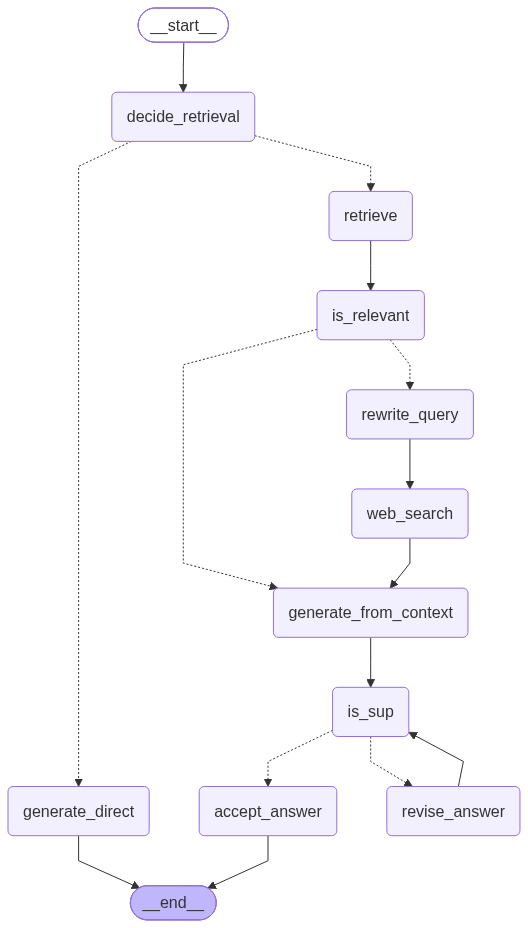

In [36]:
# -----------------------------
# Build graph (REVISED: Tavily fallback + accept/revise loop)
# -----------------------------
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)
g.add_node("generate_from_context", generate_from_context)

g.add_node("is_sup", is_sup)

# Revision nodes
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

# If relevant docs found -> generate_from_context, else -> web fallback (rewrite_query)
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "rewrite_query": "rewrite_query"},
)

# Web fallback flow: rewrite_query -> web_search -> generate_from_context
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "generate_from_context")

# --------------------
# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported -> accept_answer else revise_answer
    {"accept_answer": "accept_answer", "revise_answer": "revise_answer"},
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify
g.add_edge("accept_answer", END)

app = g.compile()
app


In [37]:
result = app.invoke(
    {
        "question": "Describe AbhiIterates company culture.",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
        "web_query": "",
    },
    config={"recursion_limit": 80},  # ✅ bump limit
)



print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 3
issup: fully_supported
evidence: ['AbhiIterates is committed to maintaining a fair, inclusive, collaborative, and quality-driven workplace for everyone who contributes to its study resources and content.', 'All contributor and team decisions are made fairly and without discrimination.']
answer: - "AbhiIterates is committed to maintaining a fair, inclusive, collaborative, and quality-driven workplace for everyone who contributes to its study resources and content."
- "All contributor and team decisions are made fairly and without discrimination."


In [38]:
# How many employees does AbhiIterates have?
# Describe AbhiIterates company culture.
# Do AbhiIterates plans include a free trial? If yes, how many days?

In [39]:
print(result.get("retries"))

1


In [20]:
for doc in result['relevant_docs']:
    print(doc.page_content)

AbhiIterates
Page 1
AbhiIterates - Company Policies
Placement-focused learning, built with integrity
HR Policies
AbhiIterates is committed to maintaining a fair, inclusive, collaborative, and quality-driven workplace
for everyone who contributes to its study resources and content.
All contributor and team decisions are made fairly and without discrimination.

Equal opportunity workplace

Bi-annual performance and growth reviews

Clear career and skill progression framework for contributors

Strict anti-harassment and respectful-workplace policy
Leave Policy
Workplace Conduct
Everyone at AbhiIterates is expected to act professionally, ethically, and responsibly at all times.

Maintain confidentiality of learner, company, partner, and project information

Avoid conflicts of interest

No acceptance of bribes or unethical gifts

Follow information security, content, and data-protection policies
Content Integrity Policy
Because AbhiIterates publishes placement and interview-preparat